# Assignment 1: NLP Text Preprocessing

**Objective:** Prepare a self-introduction paragraph and apply text preprocessing
techniques on it using Python (NLTK).

**Name:** Gokul P
**Course:** Natural Language Processing

---
### Preprocessing steps covered
1. Lowercasing
2. Removing punctuation & special characters
3. Removing numbers
4. Sentence Tokenization
5. Word Tokenization
6. Stopword Removal
7. Stemming (Porter Stemmer)
8. Lemmatization (WordNet Lemmatizer, POS-aware)
9. Part-of-Speech (POS) Tagging
10. Final cleaned text + word frequency summary


## Step 0: Install & Import Required Libraries

In [1]:
import re
import string
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.probability import FreqDist

# Download required NLTK resources (one-time)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

print("Libraries imported and NLTK resources downloaded successfully.")

[nltk_data] Downloading package punkt to /home/gokul/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/gokul/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/gokul/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/gokul/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/gokul/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/gokul/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/gokul/nltk_data...


Libraries imported and NLTK resources downloaded successfully.


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


## Step 1: Self-Introduction Paragraph

The paragraph below covers: **Name, Place, Schooling, Family, Current status,
Achievements, Hobbies, Interests, Strengths, Weaknesses**.

> Edit the text in `[square brackets]` with your own specific details before
> submitting — the rest of the pipeline works on whatever paragraph you put here.

In [3]:
paragraph = """
Hello everyone, my name is Gokul P and I am from Kerala, India. I completed my
schooling at Ghss Ottappalam, Kerala, before moving on to higher studies.
I come from a small and supportive family who have always encouraged my
curiosity for technology and learning. I am currently pursuing a B.Tech in
Computer Science Engineering (AI) at Adi Shankara Institute of Engineering and
Technology (ASIET), Kerala, and I am set to graduate in 2027. At present, I am
also working as a Machine Learning and Vision-Language Model Intern at IIT
Kharagpur, and I previously completed an internship at IIT Ropar. Some of my
key achievements include being a National Finalist at EnCode 2026 for my
project Kairos Finance, qualifying GATE 2026, and earning NPTEL Elite and Gold
certifications in Python, Deep Learning, and Artificial Intelligence. My
hobbies include participating in Capture The Flag, or CTF, competitions,
maintaining my own home lab, and contributing to open-source software such as
my GNOME Shell extension called Bastion. I am deeply interested in machine
learning, computer vision, and natural language processing! My strengths
include strong analytical thinking, quick adaptability to new tools, and
effective communication, which I have practiced through invited talks for the
IEEE Computer Society. One of my weaknesses is that I sometimes spend too much
time perfecting small details instead of moving forward quickly, but I am
actively working on improving this through better time management.
"""

print("ORIGINAL PARAGRAPH:\n")
print(paragraph.strip())
print("\nTotal characters:", len(paragraph))

ORIGINAL PARAGRAPH:

Hello everyone, my name is Gokul P and I am from Kerala, India. I completed my
schooling at Ghss Ottappalam, Kerala, before moving on to higher studies.
I come from a small and supportive family who have always encouraged my
curiosity for technology and learning. I am currently pursuing a B.Tech in
Computer Science Engineering (AI) at Adi Shankara Institute of Engineering and
Technology (ASIET), Kerala, and I am set to graduate in 2027. At present, I am
also working as a Machine Learning and Vision-Language Model Intern at IIT
Kharagpur, and I previously completed an internship at IIT Ropar. Some of my
key achievements include being a National Finalist at EnCode 2026 for my
project Kairos Finance, qualifying GATE 2026, and earning NPTEL Elite and Gold
certifications in Python, Deep Learning, and Artificial Intelligence. My
hobbies include participating in Capture The Flag, or CTF, competitions,
maintaining my own home lab, and contributing to open-source software s

## Step 2: Lowercasing

Converting all text to lowercase ensures words like `"AI"` and `"ai"` are
treated identically during analysis.

In [4]:
text_lower = paragraph.lower()
print(text_lower)


hello everyone, my name is gokul p and i am from kerala, india. i completed my
schooling at ghss ottappalam, kerala, before moving on to higher studies.
i come from a small and supportive family who have always encouraged my
curiosity for technology and learning. i am currently pursuing a b.tech in
computer science engineering (ai) at adi shankara institute of engineering and
technology (asiet), kerala, and i am set to graduate in 2027. at present, i am
also working as a machine learning and vision-language model intern at iit
kharagpur, and i previously completed an internship at iit ropar. some of my
key achievements include being a national finalist at encode 2026 for my
project kairos finance, qualifying gate 2026, and earning nptel elite and gold
certifications in python, deep learning, and artificial intelligence. my
hobbies include participating in capture the flag, or ctf, competitions,
maintaining my own home lab, and contributing to open-source software such as
my gnome shel

## Step 3: Removing Punctuation & Special Characters

Punctuation marks don't usually carry semantic meaning for tasks like
bag-of-words or frequency analysis, so we strip them out.

In [5]:
text_no_punct = text_lower.translate(str.maketrans('', '', string.punctuation))
# Also remove any stray special characters / newlines
text_no_punct = re.sub(r'[^a-z0-9\s]', '', text_no_punct)
text_no_punct = re.sub(r'\s+', ' ', text_no_punct).strip()

print(text_no_punct)

hello everyone my name is gokul p and i am from kerala india i completed my schooling at ghss ottappalam kerala before moving on to higher studies i come from a small and supportive family who have always encouraged my curiosity for technology and learning i am currently pursuing a btech in computer science engineering ai at adi shankara institute of engineering and technology asiet kerala and i am set to graduate in 2027 at present i am also working as a machine learning and visionlanguage model intern at iit kharagpur and i previously completed an internship at iit ropar some of my key achievements include being a national finalist at encode 2026 for my project kairos finance qualifying gate 2026 and earning nptel elite and gold certifications in python deep learning and artificial intelligence my hobbies include participating in capture the flag or ctf competitions maintaining my own home lab and contributing to opensource software such as my gnome shell extension called bastion i a

## Step 4: Removing Numbers

Numbers (e.g. years like 2027) are often removed when they are not relevant
to the downstream NLP task.

In [6]:
text_no_numbers = re.sub(r'\d+', '', text_no_punct)
text_no_numbers = re.sub(r'\s+', ' ', text_no_numbers).strip()

print(text_no_numbers)

hello everyone my name is gokul p and i am from kerala india i completed my schooling at ghss ottappalam kerala before moving on to higher studies i come from a small and supportive family who have always encouraged my curiosity for technology and learning i am currently pursuing a btech in computer science engineering ai at adi shankara institute of engineering and technology asiet kerala and i am set to graduate in at present i am also working as a machine learning and visionlanguage model intern at iit kharagpur and i previously completed an internship at iit ropar some of my key achievements include being a national finalist at encode for my project kairos finance qualifying gate and earning nptel elite and gold certifications in python deep learning and artificial intelligence my hobbies include participating in capture the flag or ctf competitions maintaining my own home lab and contributing to opensource software such as my gnome shell extension called bastion i am deeply intere

## Step 5: Sentence Tokenization

Splitting the *original* paragraph into individual sentences.

In [7]:
sentences = sent_tokenize(paragraph.strip())
print(f"Number of sentences: {len(sentences)}\n")
for i, s in enumerate(sentences, 1):
    print(f"{i}. {s.strip()}")

Number of sentences: 10

1. Hello everyone, my name is Gokul P and I am from Kerala, India.
2. I completed my
schooling at Ghss Ottappalam, Kerala, before moving on to higher studies.
3. I come from a small and supportive family who have always encouraged my
curiosity for technology and learning.
4. I am currently pursuing a B.Tech in
Computer Science Engineering (AI) at Adi Shankara Institute of Engineering and
Technology (ASIET), Kerala, and I am set to graduate in 2027.
5. At present, I am
also working as a Machine Learning and Vision-Language Model Intern at IIT
Kharagpur, and I previously completed an internship at IIT Ropar.
6. Some of my
key achievements include being a National Finalist at EnCode 2026 for my
project Kairos Finance, qualifying GATE 2026, and earning NPTEL Elite and Gold
certifications in Python, Deep Learning, and Artificial Intelligence.
7. My
hobbies include participating in Capture The Flag, or CTF, competitions,
maintaining my own home lab, and contributing 

## Step 6: Word Tokenization

Splitting the cleaned text (lowercased, punctuation/number-free) into
individual word tokens.

In [8]:
word_tokens = word_tokenize(text_no_numbers)
print(f"Number of word tokens: {len(word_tokens)}\n")
print(word_tokens)

Number of word tokens: 232

['hello', 'everyone', 'my', 'name', 'is', 'gokul', 'p', 'and', 'i', 'am', 'from', 'kerala', 'india', 'i', 'completed', 'my', 'schooling', 'at', 'ghss', 'ottappalam', 'kerala', 'before', 'moving', 'on', 'to', 'higher', 'studies', 'i', 'come', 'from', 'a', 'small', 'and', 'supportive', 'family', 'who', 'have', 'always', 'encouraged', 'my', 'curiosity', 'for', 'technology', 'and', 'learning', 'i', 'am', 'currently', 'pursuing', 'a', 'btech', 'in', 'computer', 'science', 'engineering', 'ai', 'at', 'adi', 'shankara', 'institute', 'of', 'engineering', 'and', 'technology', 'asiet', 'kerala', 'and', 'i', 'am', 'set', 'to', 'graduate', 'in', 'at', 'present', 'i', 'am', 'also', 'working', 'as', 'a', 'machine', 'learning', 'and', 'visionlanguage', 'model', 'intern', 'at', 'iit', 'kharagpur', 'and', 'i', 'previously', 'completed', 'an', 'internship', 'at', 'iit', 'ropar', 'some', 'of', 'my', 'key', 'achievements', 'include', 'being', 'a', 'national', 'finalist', 'at', '

## Step 7: Stopword Removal

Common words (*the, is, and, at, ...*) carry little topical meaning and are
filtered out using NLTK's English stopword list.

In [9]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in word_tokens if w not in stop_words]

print(f"Tokens before stopword removal: {len(word_tokens)}")
print(f"Tokens after stopword removal:  {len(filtered_tokens)}\n")
print(filtered_tokens)

Tokens before stopword removal: 232
Tokens after stopword removal:  139

['hello', 'everyone', 'name', 'gokul', 'p', 'kerala', 'india', 'completed', 'schooling', 'ghss', 'ottappalam', 'kerala', 'moving', 'higher', 'studies', 'come', 'small', 'supportive', 'family', 'always', 'encouraged', 'curiosity', 'technology', 'learning', 'currently', 'pursuing', 'btech', 'computer', 'science', 'engineering', 'ai', 'adi', 'shankara', 'institute', 'engineering', 'technology', 'asiet', 'kerala', 'set', 'graduate', 'present', 'also', 'working', 'machine', 'learning', 'visionlanguage', 'model', 'intern', 'iit', 'kharagpur', 'previously', 'completed', 'internship', 'iit', 'ropar', 'key', 'achievements', 'include', 'national', 'finalist', 'encode', 'project', 'kairos', 'finance', 'qualifying', 'gate', 'earning', 'nptel', 'elite', 'gold', 'certifications', 'python', 'deep', 'learning', 'artificial', 'intelligence', 'hobbies', 'include', 'participating', 'capture', 'flag', 'ctf', 'competitions', 'maintain

## Step 8: Stemming (Porter Stemmer)

Stemming chops words down to their root form (often crudely) e.g.
`"studying" -> "studi"`.

In [10]:
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(w) for w in filtered_tokens]

print(stemmed_tokens)

['hello', 'everyon', 'name', 'gokul', 'p', 'kerala', 'india', 'complet', 'school', 'ghss', 'ottappalam', 'kerala', 'move', 'higher', 'studi', 'come', 'small', 'support', 'famili', 'alway', 'encourag', 'curios', 'technolog', 'learn', 'current', 'pursu', 'btech', 'comput', 'scienc', 'engin', 'ai', 'adi', 'shankara', 'institut', 'engin', 'technolog', 'asiet', 'kerala', 'set', 'graduat', 'present', 'also', 'work', 'machin', 'learn', 'visionlanguag', 'model', 'intern', 'iit', 'kharagpur', 'previous', 'complet', 'internship', 'iit', 'ropar', 'key', 'achiev', 'includ', 'nation', 'finalist', 'encod', 'project', 'kairo', 'financ', 'qualifi', 'gate', 'earn', 'nptel', 'elit', 'gold', 'certif', 'python', 'deep', 'learn', 'artifici', 'intellig', 'hobbi', 'includ', 'particip', 'captur', 'flag', 'ctf', 'competit', 'maintain', 'home', 'lab', 'contribut', 'opensourc', 'softwar', 'gnome', 'shell', 'extens', 'call', 'bastion', 'deepli', 'interest', 'machin', 'learn', 'comput', 'vision', 'natur', 'languag

## Step 9: Lemmatization (POS-aware WordNet Lemmatizer)

Lemmatization reduces words to their dictionary (base) form using vocabulary
and morphological analysis, e.g. `"studying" -> "study"`. Providing the
correct Part-of-Speech tag to the lemmatizer greatly improves accuracy, so we
map NLTK POS tags to WordNet POS tags first.

In [11]:
def get_wordnet_pos(tag):
    """Map a Treebank POS tag to a WordNet POS tag for accurate lemmatization."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

lemmatizer = WordNetLemmatizer()
pos_tags = nltk.pos_tag(filtered_tokens)
lemmatized_tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in pos_tags]

print(lemmatized_tokens)

['hello', 'everyone', 'name', 'gokul', 'p', 'kerala', 'india', 'complete', 'school', 'ghss', 'ottappalam', 'kerala', 'move', 'high', 'study', 'come', 'small', 'supportive', 'family', 'always', 'encourage', 'curiosity', 'technology', 'learn', 'currently', 'pursue', 'btech', 'computer', 'science', 'engineering', 'ai', 'adi', 'shankara', 'institute', 'engineering', 'technology', 'asiet', 'kerala', 'set', 'graduate', 'present', 'also', 'work', 'machine', 'learn', 'visionlanguage', 'model', 'intern', 'iit', 'kharagpur', 'previously', 'complete', 'internship', 'iit', 'ropar', 'key', 'achievement', 'include', 'national', 'finalist', 'encode', 'project', 'kairos', 'finance', 'qualify', 'gate', 'earn', 'nptel', 'elite', 'gold', 'certification', 'python', 'deep', 'learning', 'artificial', 'intelligence', 'hobby', 'include', 'participate', 'capture', 'flag', 'ctf', 'competition', 'maintain', 'home', 'lab', 'contribute', 'opensource', 'software', 'gnome', 'shell', 'extension', 'call', 'bastion', '

## Step 10: Part-of-Speech (POS) Tagging

Labelling each (stopword-filtered) token with its grammatical role
(noun, verb, adjective, etc.).

In [11]:
print(f"{'Token':<15}{'POS Tag'}")
print("-" * 25)
for word, tag in pos_tags[:20]:
    print(f"{word:<15}{tag}")
print("... (showing first 20 of", len(pos_tags), "tokens)")

Token          POS Tag
-------------------------
hello          NN
everyone       NN
name           NN
gokul          NN
p              NN
kerala         NN
india          NN
completed      VBD
schooling      JJ
school         NN
name           NN
kerala         VBD
moving         VBG
higher         JJR
studies        NNS
come           VBP
small          JJ
supportive     JJ
family         NN
always         RB
... (showing first 20 of 139 tokens)


## Step 11: Final Comparison — Before vs. After Preprocessing

In [12]:
print("=" * 70)
print("BEFORE PREPROCESSING (raw paragraph, first 200 chars)")
print("=" * 70)
print(paragraph.strip()[:200] + " ...")

print("\n" + "=" * 70)
print("AFTER PREPROCESSING (cleaned, stopword-removed, lemmatized tokens)")
print("=" * 70)
final_text = " ".join(lemmatized_tokens)
print(final_text)

print(f"\nOriginal word count : {len(paragraph.split())}")
print(f"Final token count    : {len(lemmatized_tokens)}")

BEFORE PREPROCESSING (raw paragraph, first 200 chars)
Hello everyone, my name is Gokul P and I am from Kerala, India. I completed my
schooling at Ghss Ottappalam, Kerala, before moving on to higher studies.
I come from a small and supportive family who h ...

AFTER PREPROCESSING (cleaned, stopword-removed, lemmatized tokens)
hello everyone name gokul p kerala india complete school ghss ottappalam kerala move high study come small supportive family always encourage curiosity technology learn currently pursue btech computer science engineering ai adi shankara institute engineering technology asiet kerala set graduate present also work machine learn visionlanguage model intern iit kharagpur previously complete internship iit ropar key achievement include national finalist encode project kairos finance qualify gate earn nptel elite gold certification python deep learning artificial intelligence hobby include participate capture flag ctf competition maintain home lab contribute opensource s

## Step 12 (Bonus): Word Frequency Distribution

A quick frequency analysis of the cleaned tokens, visualized as a bar chart —
useful evidence that preprocessing worked as expected.

Top 10 most frequent tokens:
  kerala         3
  learn          3
  computer       3
  include        3
  complete       2
  move           2
  small          2
  technology     2
  engineering    2
  work           2


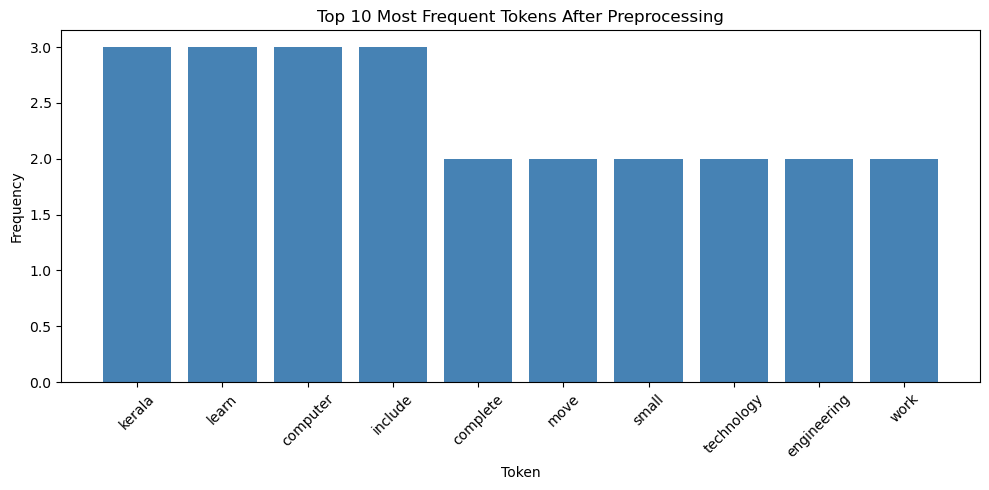

In [13]:
freq_dist = FreqDist(lemmatized_tokens)
print("Top 10 most frequent tokens:")
for word, count in freq_dist.most_common(10):
    print(f"  {word:<15}{count}")

plt.figure(figsize=(10, 5))
words, counts = zip(*freq_dist.most_common(10))
plt.bar(words, counts, color='steelblue')
plt.title("Top 10 Most Frequent Tokens After Preprocessing")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()